# Verify OCT Rotation

Verify the rotation of OCT frames by interpolated angles using rotate_oct.py

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pydicom import dcmread
import os
from pathlib import Path
import random
import re

# Read in data
oct_sb_labels = pd.read_csv('/home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/external/OCT_SB_labels.csv')

# Function to search for file path in subdirectories
def file_search(search_dir, filename):

    file_path = next(
        (f for f in search_dir.rglob(filename) if f.is_file()),
        None
    )

    if file_path:
        print(f"Found: {file_path}")
    else:
        print(f"No file found for {filename}")

    return file_path

In [ ]:
# Choose vessel to compare and analyse 
filename = oct_sb_labels["filename"].sample(n=1).iloc[0]
filename = filename.removesuffix(".jpg")
filename = filename[5:]
filename = re.sub(r"_\d{4}$", "", filename)
print(filename)

 # Choose pixel array to visualise 

BERN-156-RCA_BL


### Check original DICOMS

Found: /home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/external/DICOMS/BERN-156-RCA_BL/BERN-156-RCA_BL.dcm
(375, 1024, 1024)


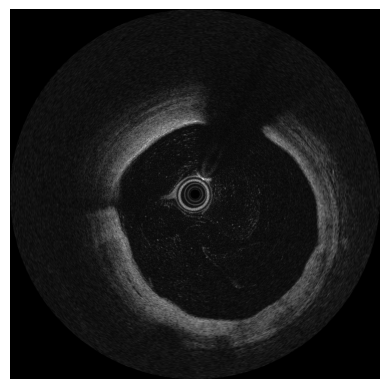

In [ ]:
dicom_dir = Path('/home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/external/DICOMS')
dicom_file = filename + '.dcm'

dicom_path = file_search(dicom_dir, dicom_file)

# Check shape of DICOMs
ds = dcmread(file_path)
arr = ds.pixel_array
print(arr.shape)

# Visualise
plt.imshow(ds.pixel_array[1], cmap="gray")
plt.axis("off")
plt.show()

## Check rotated OCT

In [ ]:
# For the purpose of testing, pick a name 
test_file = 'BERN-041-RCA_FU'

# Add the suffix
rotated_file = test_file + "_rotated.npy"

# Search in folder
dir = Path('/home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/raw/rotated_octs')
rotated_path = file_search(dir, rotated_file)


Found: /home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/raw/rotated_octs/BERN-041-RCA_FU_rotated.npy


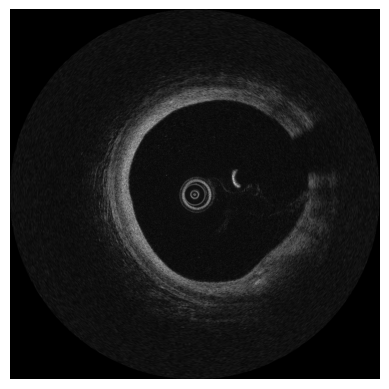

In [26]:
image_arr = np.load(rotated_path)
image_arr.shape

# Visualise
plt.imshow(image_arr[1], cmap="gray")
plt.axis("off")
plt.show()